In [1]:
# Example 6.9: Lagrange interpolation (in class)

# x: value at which we want to evaluate the interpolator
# xi: independent variable, gi: dependent variable
def LagrangeInterp(x, xi, gi, n):
    # check that length of data is divisible by n
    npoints = len(gi)
    if n>2 and  npoints%n != 0:
        print('n does not divide the number of data points')
        exit()
    # first decide which interval we fall in for the interpolation
    for k in range(npoints-1):
        if x >= xi[k] and x < xi[k+1]:
            location = k
            break
    g = 0
    # check edge scenarios (first bin and last bin)
    if location == 0 or n==2:
        location +=1 
    if n==len(gi):
        location=1
    for i in range(location-1, location+n-1):
        lambdaxi = 1
        for j in range(location-1, location+n-1):
            if i != j:
                lambdaxi *= (x - xi[j])/(xi[i] - xi[j])
        g += gi[i] * lambdaxi
    return g

# Before we interpolate let's plot:
    

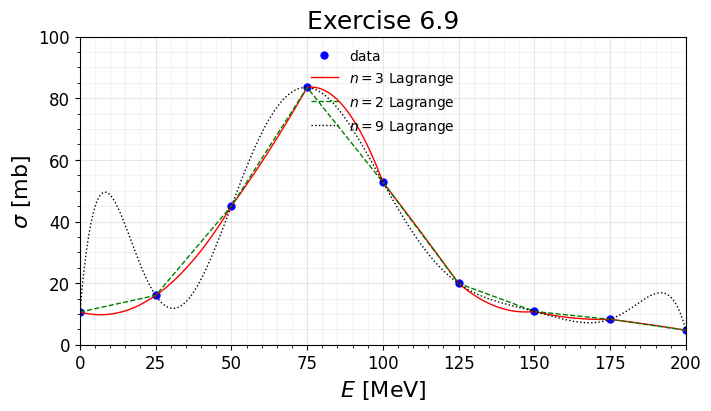

In [3]:
import matplotlib.pyplot as plt  # import matplotlib, a conventional module name is plt
import numpy as np

# input data
xdata = [0, 25, 50, 75, 100, 125, 150, 175, 200]
gdata = [10.6, 16.0, 45.0, 83.5, 52.8, 19.9, 10.8, 8.25, 4.7]

# interpolate 
xinterp = np.linspace(0.001, 199.99, 1000)
ninterp = 3
ginterp3 = [LagrangeInterp(x, xdata, gdata, ninterp) for x in xinterp]
ninterp = 2
ginterp2 = [LagrangeInterp(x, xdata, gdata, ninterp) for x in xinterp]
ninterp = 9
ginterp9 = [LagrangeInterp(x, xdata, gdata, ninterp) for x in xinterp]

# create the elements required for matplotlib. This creates a figure containing a single axes.
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

# set the labels and titles (include units where appropriate):
ax.set_xlabel(r'$E$ [MeV]', fontsize=16)     # set the x label
ax.set_ylabel(r'$\sigma$ [mb]', fontsize=16)        # set the y label
ax.set_title('Exercise 6.9', fontsize=18)  # set the title

# set the x and y limits:
ax.set_xlim(0, 200)
ax.set_ylim(0, 100)

# make one-dimensional plots using the above arrays, add labels, line styles and colors:
ax.plot(xdata, gdata, color='blue', linestyle='', marker='o', ms=5, linewidth=0, label='data')
ax.plot(xinterp, ginterp3, color='red', linestyle='-', marker='o', ms=0, linewidth=1, label='$n=3$ Lagrange')
ax.plot(xinterp, ginterp2, color='green', linestyle='--', marker='o', ms=0, linewidth=1, label='$n=2$ Lagrange')
ax.plot(xinterp, ginterp9, color='black', linestyle=':', marker='o', ms=0, linewidth=1, label='$n=9$ Lagrange')

# optional: add a light grid to help read off values (without dominating the plot)
ax.grid(True, which='major', alpha=0.3)
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.15)

# make tick labels readable
ax.tick_params(axis='both', which='major', labelsize=12)

# construct the legend (avoid covering important data)
ax.legend(loc='upper center', frameon=False)

plt.show()  # show the plot here
# if you want to save the plot:
# filename = 'myplot.pdf'
# fig.savefig(filename, dpi=dpi, bbox_inches="tight")